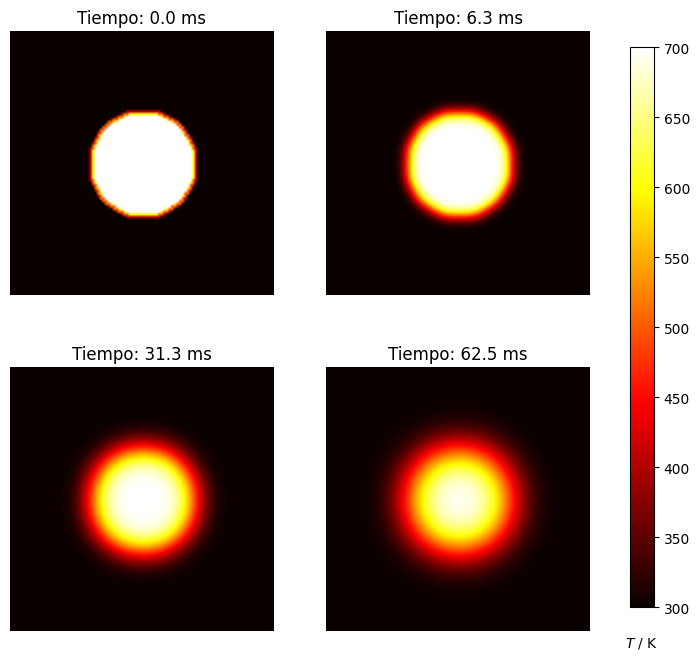

In [1]:
import numpy as np
import matplotlib.pyplot as plt

w = h = 10.0           # Tamaño de la placa (mm)
dx = dy = 0.1          # Resolución espacial (mm)
D = 4.0                # Difusividad térmica del acero (mm2/s)
Tcool, Thot = 300, 700 # Temperaturas (Kelvin)

#  Discretización
nx, ny = int(w / dx), int(h / dy)
dx2, dy2 = dx * dx, dy * dy
# Paso de tiempo según condición de estabilidad
dt = dx2 * dy2 / (2 * D * (dx2 + dy2))

#  Inicialización
u0 = Tcool * np.ones((nx, ny))
u = u0.copy()

# Crear el disco caliente central
r, cx, cy = 2, 5, 5
r2 = r**2
for i in range(nx):
    for j in range(ny):
        p2 = (i * dx - cx) ** 2 + (j * dy - cy) ** 2
        if p2 < r2:
            u0[i, j] = Thot

#  Función de paso de tiempo (Vectorizada)
def do_timestep(u0, u):
    # FDM: Diferencia adelante en tiempo, central en espacio
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D * dt * (
        (u0[2:, 1:-1] - 2 * u0[1:-1, 1:-1] + u0[:-2, 1:-1]) / dx2
        + (u0[1:-1, 2:] - 2 * u0[1:-1, 1:-1] + u0[1:-1, :-2]) / dy2
    )
    u0 = u.copy()
    return u0, u

#  Bucle principal y Graficación
nsteps = 101
mfig = [0, 10, 50, 100] # Pasos donde tomaremos fotos
fignum = 0
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

for m in range(nsteps):
    u0, u = do_timestep(u0, u)
    if m in mfig:
        ax = axes[fignum // 2, fignum % 2]
        im = ax.imshow(u.copy(), cmap="hot", vmin=Tcool, vmax=Thot, interpolation="bilinear")
        ax.set_axis_off()
        ax.set_title(f"Tiempo: {m * dt * 1000:.1f} ms")
        fignum += 1

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()